In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive/emg2qwerty

/content/drive/MyDrive/emg2qwerty


In [4]:
ls

CODE_OF_CONDUCT.md    LICENSE                 resnet_train_output.txt
Colab_setup.ipynb     logs/                   resnet_v2_test_output.txt
config/               models/                 resnet_v2_train_output.txt
CONTRIBUTING.md       parser.ipynb            scripts/
data/                 README.md               setup.cfg
emg2qwerty/           requirements.txt        setup.py
emg2qwerty.egg-info/  resnet.ipynb            transformer.ipynb
environment.yml       resnet_test_output.txt  transformer_train_output.txt


Loaded 4435 lines from training log
Epochs tracked: 0 - 149
Final training loss: 0.3840
Best val CER: 24.26



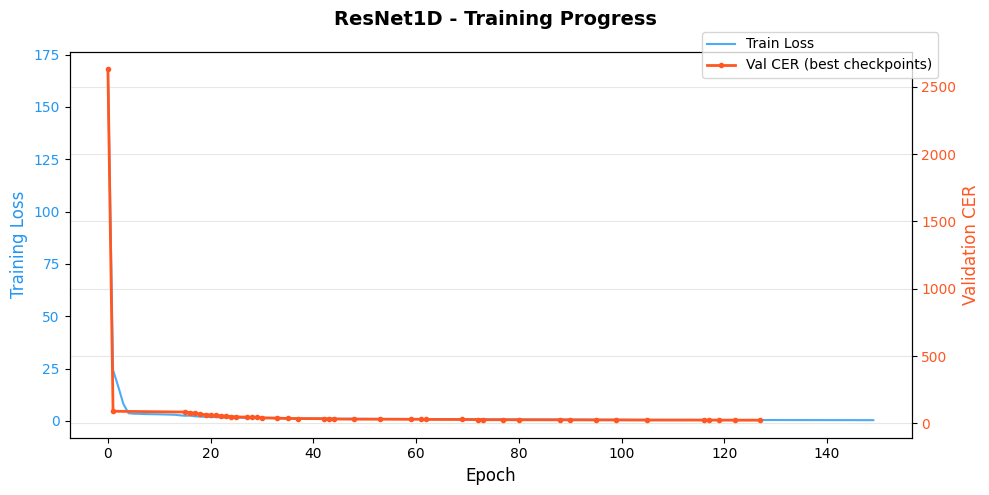

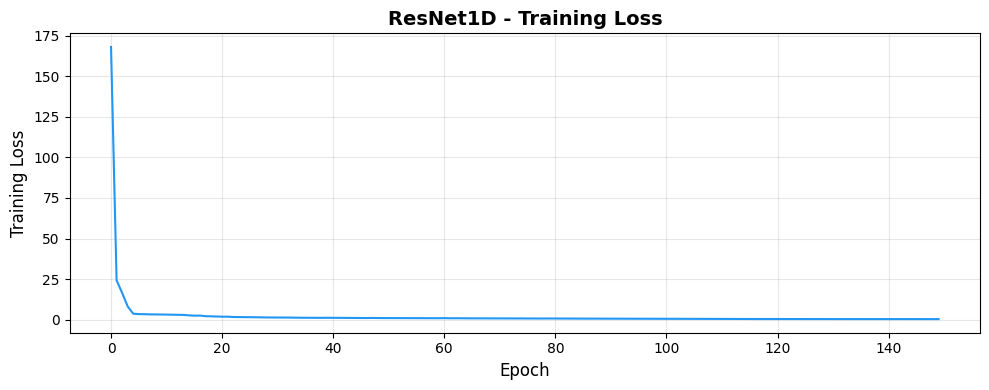

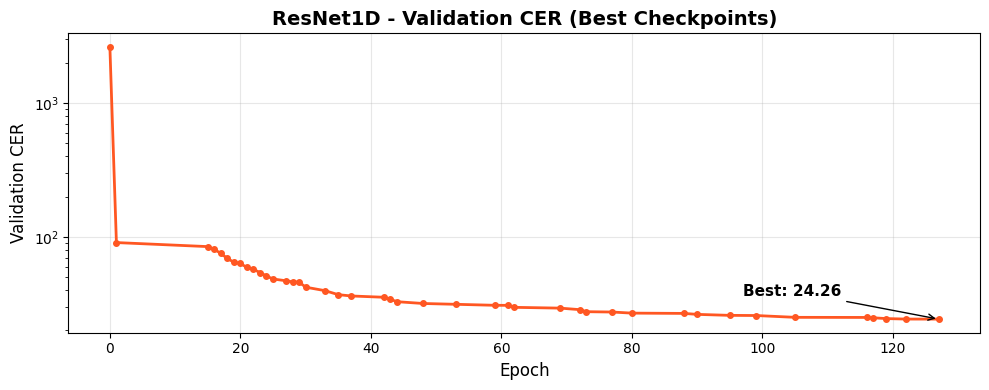

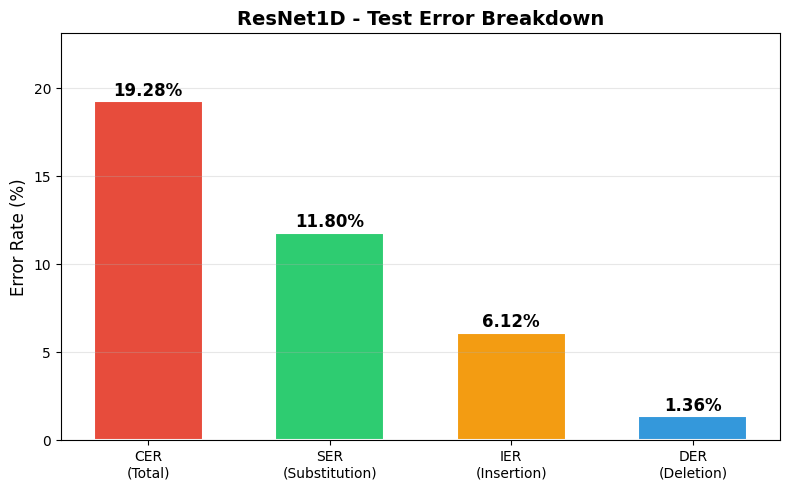

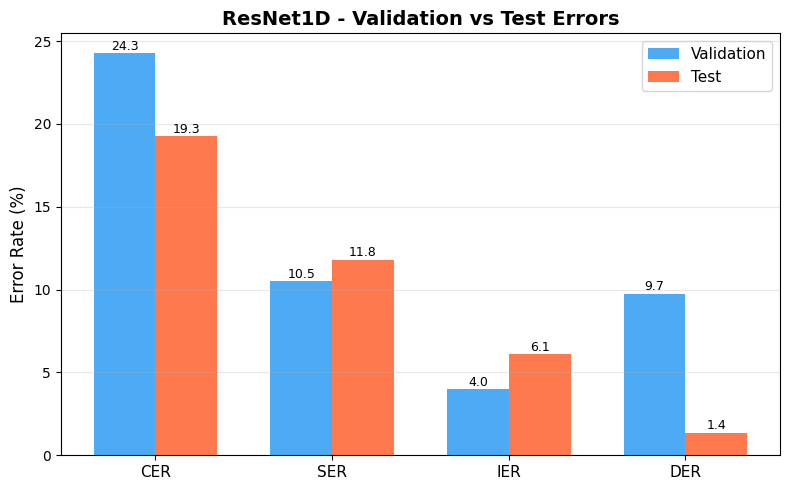

  ResNet1D - Results Summary
  Metric                 Validation         Test
  --------------------------------------------
  CER                         24.26        19.28
  SER (Substitution)          10.50        11.80
  IER (Insertion)              4.01         6.12
  DER (Deletion)               9.75         1.36
  Loss                       0.9847       0.9223


In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSE TRAINING LOG
# ============================================================
with open("resnet_v2_train_output.txt", "r", encoding="utf-8", errors="ignore") as f:
    train_lines = f.readlines()

print(f"Loaded {len(train_lines)} lines from training log")

epoch_loss = []
val_cer = []
current_epoch = None

for line in train_lines:
    epoch_match = re.search(r"Epoch\s+(\d+)", line)
    if epoch_match:
        current_epoch = int(epoch_match.group(1))

    loss_match = re.search(r"loss[=:]\s*([0-9]+(?:\.[0-9]+)?)", line)
    if loss_match and current_epoch is not None:
        epoch_loss.append((current_epoch, float(loss_match.group(1))))

    cer_match = re.search(r"'val/CER'\s+reached\s+([0-9]+(?:\.[0-9]+)?)", line)
    if cer_match and current_epoch is not None:
        val_cer.append((current_epoch, float(cer_match.group(1))))


def last_value_per_epoch(pairs):
    d = {}
    for e, v in pairs:
        d[e] = v
    return pd.DataFrame({
        "epoch": sorted(d.keys()),
        "value": [d[e] for e in sorted(d.keys())]
    })


df_loss = last_value_per_epoch(epoch_loss)
df_loss.columns = ["epoch", "train_loss"]
df_cer = last_value_per_epoch(val_cer)
df_cer.columns = ["epoch", "val_CER"]

df = pd.merge(df_loss, df_cer, on="epoch", how="outer").sort_values("epoch")
df["val_CER"] = df["val_CER"].ffill()

print(f"Epochs tracked: {int(df['epoch'].min())} - {int(df['epoch'].max())}")
print(f"Final training loss: {df['train_loss'].iloc[-1]:.4f}")
print(f"Best val CER: {df['val_CER'].min():.2f}")
print()

# ============================================================
# PARSE TEST LOG
# ============================================================
with open("resnet_v2_test_output.txt", "r", encoding="utf-8", errors="ignore") as f:
    test_lines = f.readlines()

test_metrics = {}
for line in test_lines:
    for key in ["test/CER", "test/DER", "test/SER", "test/IER", "test/loss"]:
        m = re.search(rf"'{key}':\s*([0-9]+(?:\.[0-9]+)?)", line)
        if m:
            test_metrics[key] = float(m.group(1))

# Also parse val metrics from test log
val_metrics = {}
for line in test_lines:
    for key in ["val/CER", "val/DER", "val/SER", "val/IER", "val/loss"]:
        m = re.search(rf"'{key}':\s*([0-9]+(?:\.[0-9]+)?)", line)
        if m:
            val_metrics[key] = float(m.group(1))

# ============================================================
# FIGURE 1: Training Loss + Val CER (dual axis)
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = "#2196F3"
color2 = "#FF5722"

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Training Loss", color=color1, fontsize=12)
ax1.plot(df["epoch"], df["train_loss"], color=color1, alpha=0.8, linewidth=1.5, label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel("Validation CER", color=color2, fontsize=12)
ax2.plot(df_cer["epoch"], df_cer["val_CER"], color=color2, linewidth=2, marker="o",
         markersize=3, label="Val CER (best checkpoints)")
ax2.tick_params(axis="y", labelcolor=color2)

fig.suptitle("ResNet1D - Training Progress", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95), fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# FIGURE 2: Training Loss (standalone)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df["epoch"], df["train_loss"], color="#2196F3", linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("ResNet1D - Training Loss", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 3: Validation CER (standalone)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_cer["epoch"], df_cer["val_CER"], color="#FF5722", linewidth=2, marker="o", markersize=4)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation CER", fontsize=12)
ax.set_title("ResNet1D - Validation CER (Best Checkpoints)", fontsize=14, fontweight="bold")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

# Annotate final best
best_epoch = df_cer["epoch"].iloc[-1]
best_cer = df_cer["val_CER"].iloc[-1]
ax.annotate(f"Best: {best_cer:.2f}", xy=(best_epoch, best_cer),
            xytext=(best_epoch - 30, best_cer * 1.5),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 4: Test Error Breakdown
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["CER\n(Total)", "SER\n(Substitution)", "IER\n(Insertion)", "DER\n(Deletion)"]
values = [
    test_metrics.get("test/CER", 0),
    test_metrics.get("test/SER", 0),
    test_metrics.get("test/IER", 0),
    test_metrics.get("test/DER", 0),
]
colors = ["#e74c3c", "#2ecc71", "#f39c12", "#3498db"]

bars = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=1.5, width=0.6)
ax.set_ylabel("Error Rate (%)", fontsize=12)
ax.set_title("ResNet1D - Test Error Breakdown", fontsize=14, fontweight="bold")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.2f}%", ha="center", fontsize=12, fontweight="bold")

ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 5: Val vs Test Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

metrics = ["CER", "SER", "IER", "DER"]
val_vals = [val_metrics.get(f"val/{m}", 0) for m in metrics]
test_vals = [test_metrics.get(f"test/{m}", 0) for m in metrics]

x = range(len(metrics))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], val_vals, width, label="Validation", color="#2196F3", alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], test_vals, width, label="Test", color="#FF5722", alpha=0.8)

ax.set_ylabel("Error Rate (%)", fontsize=12)
ax.set_title("ResNet1D - Validation vs Test Errors", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}", ha="center", fontsize=9)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================
print("=" * 50)
print("  ResNet1D - Results Summary")
print("=" * 50)
print(f"  {'Metric':<20} {'Validation':>12} {'Test':>12}")
print(f"  {'-'*44}")
print(f"  {'CER':<20} {val_metrics.get('val/CER', 0):>12.2f} {test_metrics.get('test/CER', 0):>12.2f}")
print(f"  {'SER (Substitution)':<20} {val_metrics.get('val/SER', 0):>12.2f} {test_metrics.get('test/SER', 0):>12.2f}")
print(f"  {'IER (Insertion)':<20} {val_metrics.get('val/IER', 0):>12.2f} {test_metrics.get('test/IER', 0):>12.2f}")
print(f"  {'DER (Deletion)':<20} {val_metrics.get('val/DER', 0):>12.2f} {test_metrics.get('test/DER', 0):>12.2f}")
print(f"  {'Loss':<20} {val_metrics.get('val/loss', 0):>12.4f} {test_metrics.get('test/loss', 0):>12.4f}")
print("=" * 50)